In [18]:
"""
PROJECT TITLE: Oxymove (MOXY)
--------------------------------------------------
DESCRIPTION:
    This script processes raw NIRS data file collected with the Artinis Portalite and Semaxone devices during concentric or eccentric tasks.
    The script converts raw optical density data to hemoglobin concentration changes, applies a low-pass filter, and plots the results around specific event markers.

    It uses a two-files approach: one main notebook and one helper module.
    The helper module performs loading, preprocessing, channel selection, trial extraction, envelope/AUC computation, plotting, and CSV export.
    Channel selection is explicit: Portalite uses S2_D1, while Semaxone averages S2_D1, S2_D3, S1_D2, and S1_D4.

AUTHOR: Devaux Yann (EuroMov DHM / University of Montpellier)
CONTACT: yann.devaux@etu.umontpellier.fr
CREATED: 03/03/2026
VERSION: 1.1

WARNING : Be careful, this script is optimized for python 3.12 and libraries versions may cause issues if not compatible.

INPUTS:
    - Compressed raw NIRS data (.snirf)
    - Event markers file (.tsv)
    - Configuration file (.json)

OUTPUTS:
    - raw and filtered Hb plots
    - HbR group mean plots without connecting lines between intensities
    - envelope and AUC figures per device and per trial
    - trial-level CSV exports for R/statistical analysis in Analysis_Results

LIBRARIES:
    Mne, Matplotlib, Pandas, Mne-bids, Numpy, Glob, OS
"""

'\nPROJECT TITLE: Oxymove (MOXY)\n--------------------------------------------------\nDESCRIPTION:\n    This script processes raw NIRS data file collected with the Artinis Portalite and Semaxone devices during concentric or eccentric tasks.\n    The script converts raw optical density data to hemoglobin concentration changes, applies a low-pass filter, and plots the results around specific event markers.\n\n    It uses a two-files approach: one main notebook and one helper module.\n    The helper module performs loading, preprocessing, channel selection, trial extraction, envelope/AUC computation, plotting, and CSV export.\n    Channel selection is explicit: Portalite uses S2_D1, while Semaxone averages S2_D1, S2_D3, S1_D2, and S1_D4.\n\nAUTHOR: Devaux Yann (EuroMov DHM / University of Montpellier)\nCONTACT: yann.devaux@etu.umontpellier.fr\nCREATED: 03/03/2026\nVERSION: 1.1\n\nWARNING : Be careful, this script is optimized for python 3.12 and libraries versions may cause issues if not 

## To begin : make sure you have this file and "NIRS_functions_Oxymove.py" saved in the same folder.

## To make sure to have all the required libraries installed, you can run the following command in your terminal: 

In [19]:
#pip install mne matplotlib pandas mne-bids numpy glob os warnings logging pyqt6

## Import all necessary libraires

In [20]:
import mne 
import matplotlib.pyplot as plt
import pandas as pd
from mne_bids import BIDSPath, read_raw_bids
import numpy as np
import glob
import os
import warnings
import logging

## Import the file where all the functions are located

In [21]:
import NIRS_functions_Oxymove as NIRS_oxymove

## We will use the visualization toolbox "Qt"

In [22]:
#visualisation toolkit
mne.viz.set_browser_backend("qt")

'qt'

## Some output settings

In [23]:
mne.set_log_level('ERROR')
warnings.filterwarnings('ignore')

## Participant table

In [24]:
#Print participant table to check available data
participant_table = pd.read_excel(r"C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\Miscellaneous\Randomisation_passage.xlsx")
print(participant_table)

   Participant ID participant Passage A (Session 1)  Unnamed: 3  \
0          P01         sub001          Concentrique         NaN   
1          NaN            NaN                    50        30.0   
2          P02         sub002           Excentrique         NaN   
3          NaN            NaN                    30        50.0   
4          P03         sub003           Excentrique         NaN   
5          NaN            NaN                    50        30.0   
6          P04         sub004          Concentrique         NaN   
7          NaN            NaN                    30        50.0   
8          P05         sub005          Concentrique         NaN   
9          NaN            NaN                    50        30.0   
10         P06         sub006           Excentrique         NaN   
11         NaN            NaN                    30        50.0   
12         P07         sub007          Concentrique         NaN   
13         NaN            NaN                    30        50.

## Choosing which subject, which session (**001** or **002**), what modality of contraction (**concentric** or **eccentric**) and wich device (**portalite** or **semaxone**). Refer to previous table to see subject availibility. 

In [25]:
# Choose what you want to load
subject_choice = '001'  # You can write '04' or '004'
session_choice = '001'  # You can write '2', '02', or '002'
recording_choice = ['semaxone', 'portalite']  # Portalite uses S2_D1; Semaxone averages S2_D1, S2_D3, S1_D2, and S1_D4
task_choice = None  # None = infer from session/events, or set 'concentric'/'eccentric'

# Normalize identifiers to BIDS format (sub-XXX / ses-XXX).
subject_choice = str(subject_choice).zfill(3)
session_choice = str(session_choice).zfill(3)

# Base root used by BIDSPath
BASE_ROOT = r'C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids'

# For this raw file preview, use the first selected device.
selected_recording = recording_choice[0]

# Infer task automatically when task_choice is None.
selected_task = NIRS_oxymove.infer_task_from_session(
    session_choice,
    task_choice=task_choice,
    subject_choice=subject_choice,
    base_root=BASE_ROOT,
 )

raw = BIDSPath(
    subject=subject_choice,
    session=session_choice,
    task=selected_task,
    recording=selected_recording,
    suffix='nirs',
    extension='.snirf',
    datatype='nirs',
    root=BASE_ROOT,
 )

# Fail early with a clear message if this BIDS folder does not exist.
if not os.path.isdir(raw.directory):
    raise FileNotFoundError(
        f"BIDS folder not found: {raw.directory}. "
        f"Check subject/session availability in participant table. "
        f"Current selection: sub-{subject_choice}, ses-{session_choice}."
    )

print(
    f"Using subject={subject_choice}, session={session_choice}, "
    f"task={selected_task}, recording={selected_recording}"
)

Using subject=001, session=001, task=concentric, recording=semaxone


## Converts raw signal to optical density, and then to hemoglobin concentration

In [26]:
#read raw data
raw = read_raw_bids(raw)
duration = raw.times[-1] # total duration of the recording in seconds
#raw to optical density
raw_od = mne.preprocessing.nirs.optical_density(raw)
#optical density to hemoglobin concentration changes
raw_hb = mne.preprocessing.nirs.beer_lambert_law(raw_od, ppf=4) #We chose ppf=4.0, based on Pirovano, 2020 work.  
print(raw_hb)
# Filtering with a low-pass filter (cutoff at 5 Hz) and a butterworth filter of order 4.
raw_hb_filt = raw_hb.filter(l_freq=None, h_freq=5.0, 
                            method="iir", 
                            iir_params=dict(order=4, ftype='butter'), 
                            phase="zero")
scales = dict(HbR = 20e-6, HbO = 20e-6)
raw_hb_filt.plot(start=0, duration=duration, scalings=scales, show_scrollbars=False)

<RawSNIRF | sub-001_ses-001_task-concentric_recording-semaxone_nirs.snirf, 14 x 224205 (2234.9 s), ~24.0 MiB, data loaded>


## Display channels name

In [27]:
raw_hb_filt.info
hbr = [raw_hb_filt.ch_names[i] for i in mne.pick_types(raw_hb_filt.info, fnirs='hbr')]
hbo = [raw_hb_filt.ch_names[i] for i in mne.pick_types(raw_hb_filt.info, fnirs='hbo')]

## These cells  analyze HbR concentration changes as a function of intensity for CONCENTRIC and ECCENTRIC tasks, comparing both devices: semaxone and portalite

In [28]:
BASE_ROOT = r'C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids' # Update this path to your actual data location
window_duration = 30
intensities = [30, 50]

## The following cell displays every set, for specified session. It will focus on the HbR level since it is the best one to graphically read the oxygenation kinetic

In [29]:
t_pre = 5  # Time before the event to display (in seconds)
t_post = 40  # Time after the event to display (in seconds)

Using events file: C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\ses-001\nirs\sub-001_ses-001_task-concentric_events.tsv
Trial types found: ['Con30', 'Con50']


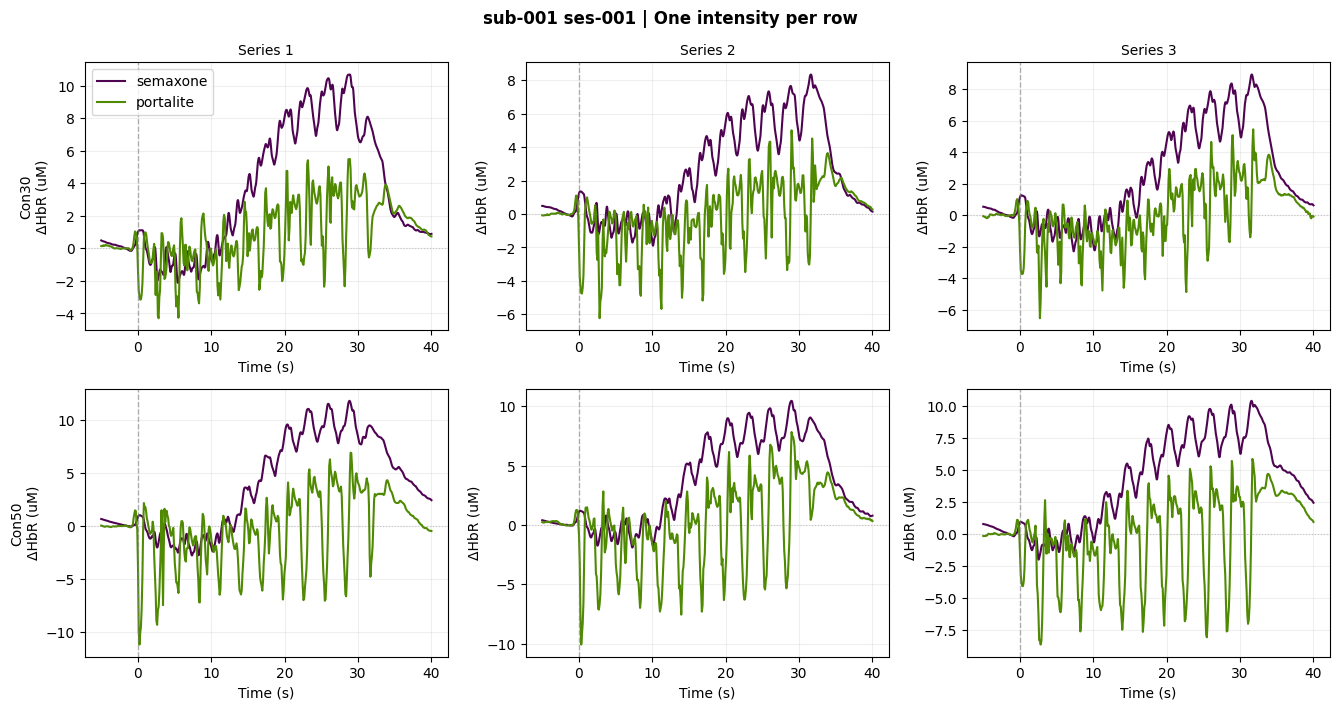

In [30]:
NIRS_oxymove.display_sets_one_by_one(
    subject_choice=subject_choice,
    session_choice=session_choice,
    recording_choice=recording_choice,
    task_choice=task_choice,
    t_pre=t_pre,
    t_post=t_post,
    base_root=BASE_ROOT,
)

## HbR/HbO only: envelope and AUC in two separate figures

Using events file: C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\ses-001\nirs\sub-001_ses-001_task-concentric_events.tsv


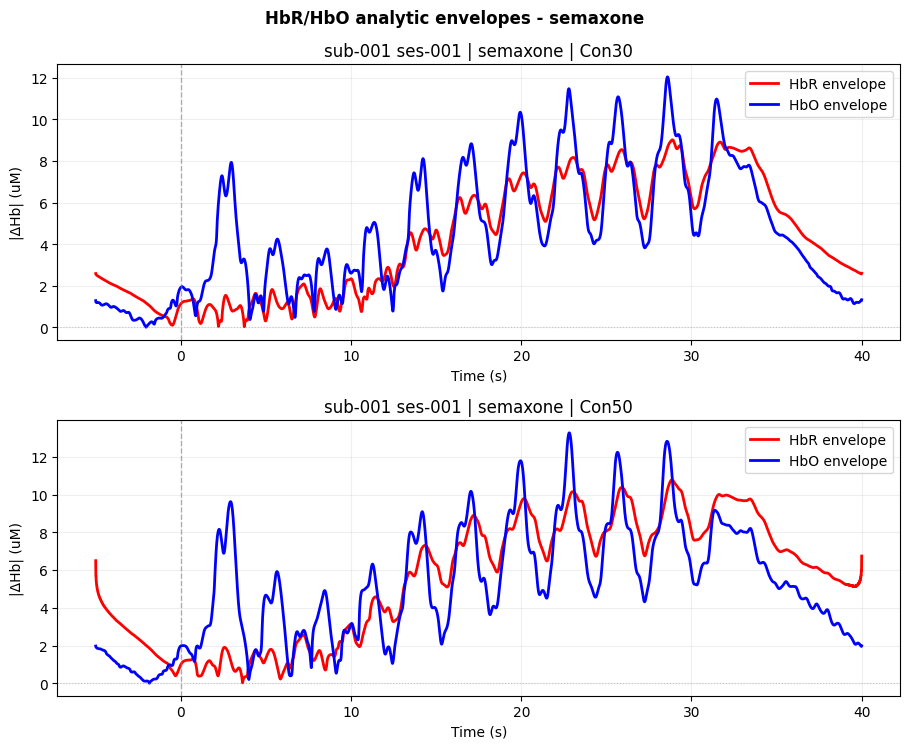

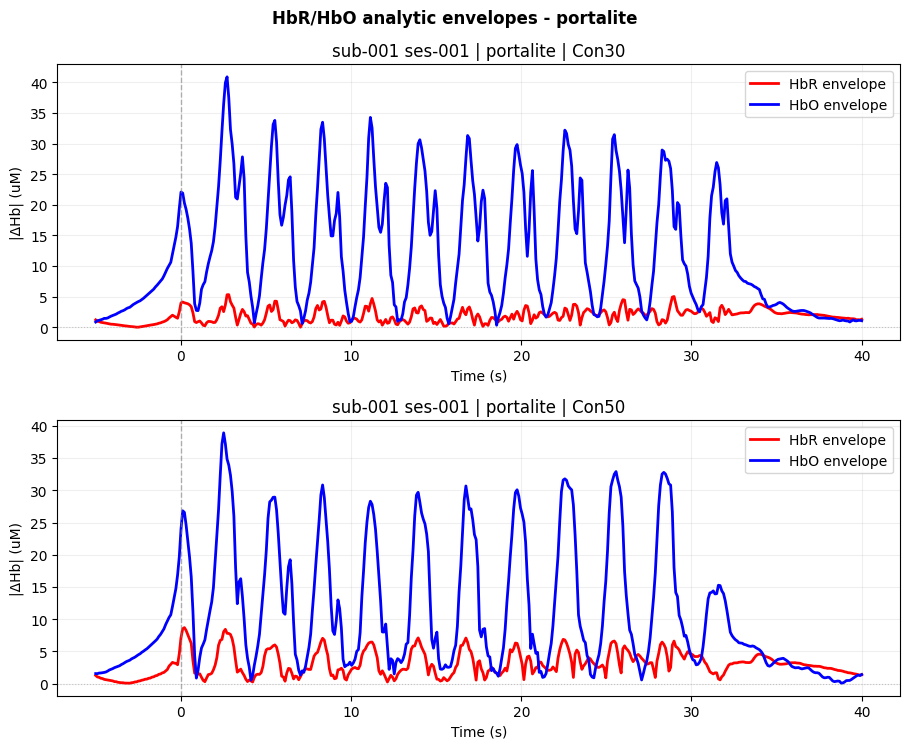

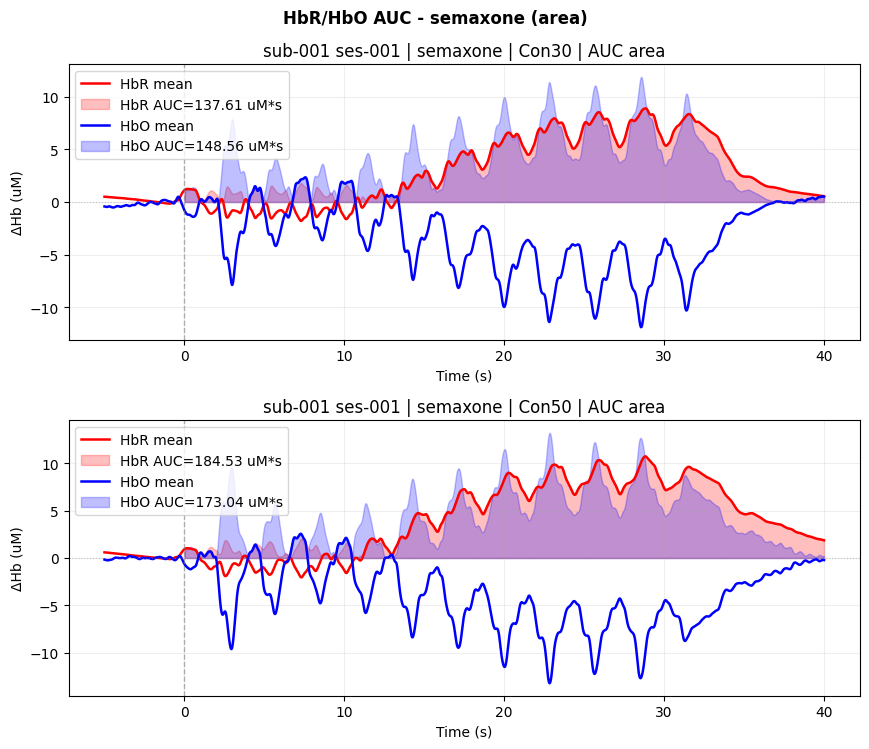

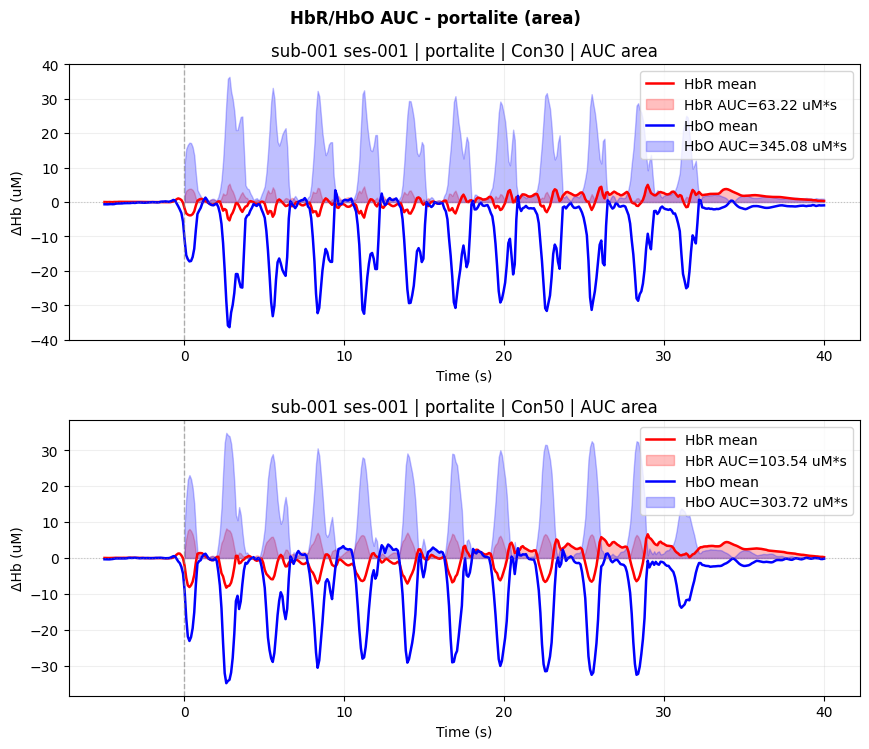

In [31]:
# HbR/HbO envelopes (abs) and AUC area, with separate figures per device.
import importlib
NIRS_oxymove = importlib.reload(NIRS_oxymove)

hb_summary = NIRS_oxymove.plot_hbr_hbo_mean_and_auc_by_device(
    subject_choice=subject_choice,
    session_choice=session_choice,
    recording_choice=recording_choice,
    task_choice=task_choice,
    t_pre=t_pre,
    t_post=t_post,
    auc_window=(0, None),
    use_abs_envelope=True,
    use_abs_auc=True,
    auc_plot_style='area',
    base_root=BASE_ROOT,
)

## Compare concentric vs eccentric envelopes (same subject, 30% and 50%)

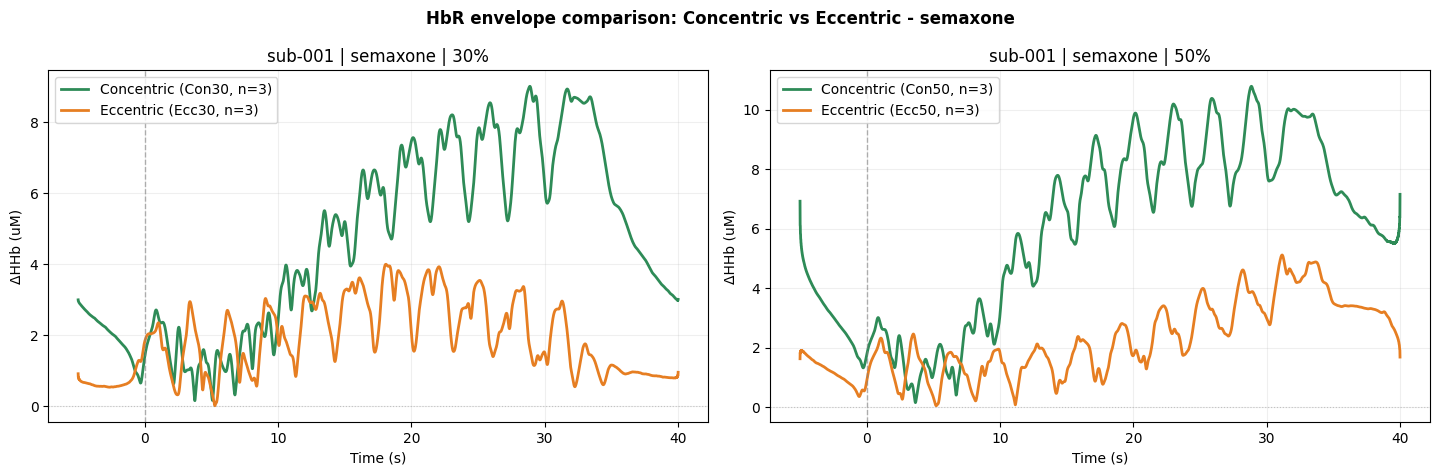

In [32]:
con_ecc_envelope_summary = NIRS_oxymove.plot_concentric_vs_eccentric_envelopes(
    subject_choice=subject_choice,
    recording_choice=['semaxone'],
    t_pre=t_pre,
    t_post=t_post,
    chromophore='HbR',
    use_abs_envelope=False,
    base_root=BASE_ROOT,
)

## The following cell compares group mean of the HbR level, regarding the contraction mode, the intensity and the device

Running comparison for 24 subject(s)...

################################################################################
SUBJECT 001
################################################################################

PROCESSING CONCENTRIC DATA - SEMAXONE (ses-001)

Processing Con30 series (semaxone)...
  Series 1: Mean HbR = 1.231 µM
  Series 2: Mean HbR = 0.574 µM
  Series 3: Mean HbR = 0.356 µM

Processing Con50 series (semaxone)...
  Series 1: Mean HbR = 0.575 µM
  Series 2: Mean HbR = 1.069 µM
  Series 3: Mean HbR = 0.592 µM

PROCESSING CONCENTRIC DATA - PORTALITE (ses-001)

Processing Con30 series (portalite)...
  Series 1: Mean HbR = -0.000 µM
  Series 2: Mean HbR = -0.316 µM
  Series 3: Mean HbR = -0.275 µM

Processing Con50 series (portalite)...
  Series 1: Mean HbR = -0.583 µM
  Series 2: Mean HbR = -0.498 µM
  Series 3: Mean HbR = -0.826 µM

PROCESSING ECCENTRIC DATA - SEMAXONE (ses-002)

Processing Ecc30 series (semaxone)...
  Series 1: Mean HbR = -0.742 µM
  Series 2: Mean H

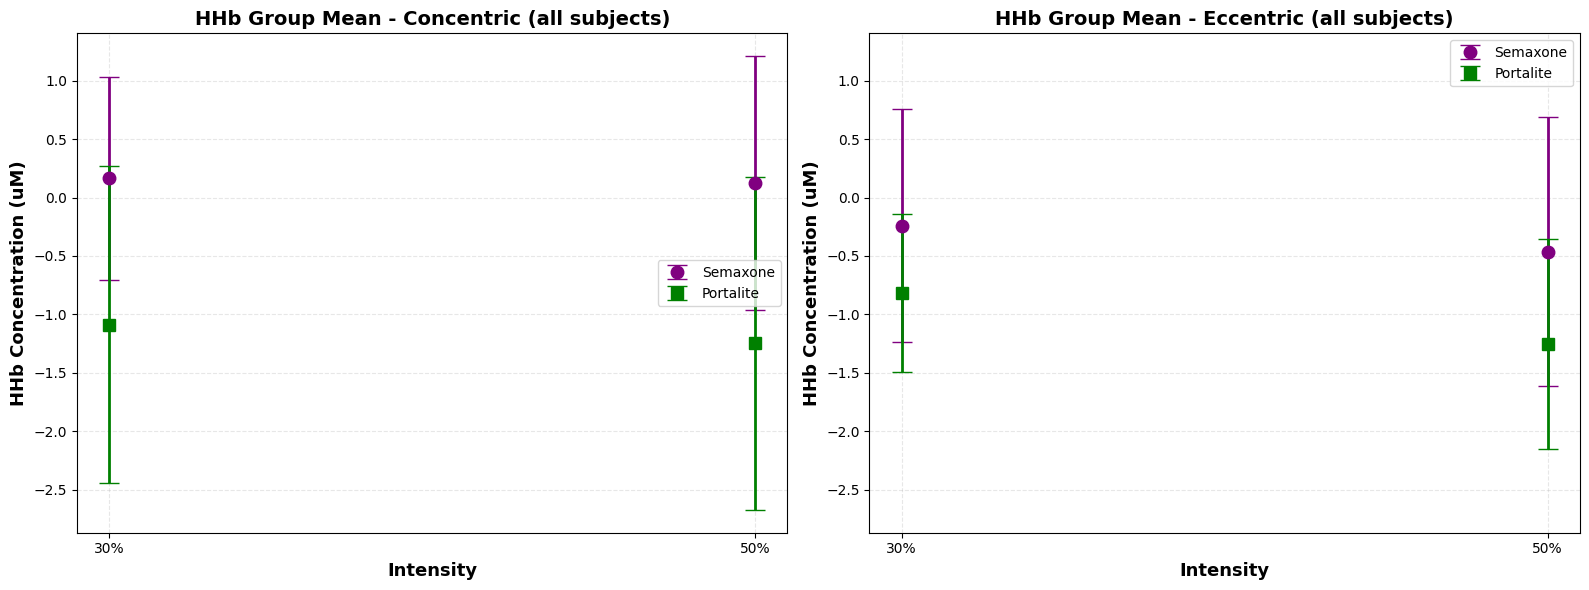

Subjects used for group mean: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024']

DESCRIPTIVE GROUP STATISTICS - HHb mean across subjects
CONCENTRIC - SEMAXONE: 30%=0.164+-0.867 (n=23), 50%=0.127+-1.085 (n=23)
CONCENTRIC - PORTALITE: 30%=-1.088+-1.359 (n=23), 50%=-1.248+-1.428 (n=23)
ECCENTRIC - SEMAXONE: 30%=-0.239+-1.000 (n=21), 50%=-0.464+-1.152 (n=20)
ECCENTRIC - PORTALITE: 30%=-0.819+-0.678 (n=22), 50%=-1.254+-0.902 (n=21)


In [33]:
group_stats = NIRS_oxymove.compare_devices_group_mean(
    subject_ids=None,  # None = all subjects found in BASE_ROOT
    base_root=BASE_ROOT,
    intensities=intensities, 
    make_plot=True, 
    print_stats=True,
)

# Keep variables available for downstream cells
globals().update(group_stats)

## Creating trial-level CSV files for both devices (with envelope and AUC metrics) for statistical analysis in R.

In [34]:
csv_exports = NIRS_oxymove.export_hb_summary_csv_by_device(
    subject_ids=None,
    base_root=BASE_ROOT,
    recordings=['portalite', 'semaxone'],
    window_duration=window_duration,
    output_dir=None,
    filename_prefix='hb_summary_final',
    include_all_participants=True,
    table_granularity='trial',  # one row per trial
    use_abs_envelope=True,      # envelope computed on absolute signal
    use_abs_auc=True,           # AUC computed on absolute signal
    print_progress=True,
)

results_df_portalite = csv_exports['portalite']['results_df']  # Trial-level table for Portalite
output_path_portalite = csv_exports['portalite']['output_path']  # CSV path for Portalite

results_df_semaxone = csv_exports['semaxone']['results_df']  # Trial-level table for Semaxone
output_path_semaxone = csv_exports['semaxone']['output_path']  # CSV path for Semaxone

if output_path_portalite is not None:
    print('\nPortalite table (trial-level):')
    print(results_df_portalite.to_string(index=False))

if output_path_semaxone is not None:
    print('\nSemaxone table (trial-level):')
    print(results_df_semaxone.to_string(index=False))

Processing sub-001 ses-001 task-concentric (portalite)
Processing sub-001 ses-002 task-eccentric (portalite)
Processing sub-002 ses-001 task-eccentric (portalite)
Processing sub-002 ses-002 task-concentric (portalite)
Processing sub-003 ses-001 task-eccentric (portalite)
Processing sub-003 ses-002 task-concentric (portalite)
Processing sub-004 ses-001 task-concentric (portalite)
Processing sub-004 ses-002 task-eccentric (portalite)
Processing sub-005 ses-001 task-concentric (portalite)
Processing sub-005 ses-002 task-eccentric (portalite)
Processing sub-006 ses-001 task-eccentric (portalite)
Processing sub-006 ses-002 task-concentric (portalite)
Processing sub-007 ses-001 task-concentric (portalite)
Processing sub-007 ses-002 task-eccentric (portalite)
Processing sub-008 ses-002 task-concentric (portalite)
Processing sub-009 ses-001 task-eccentric (portalite)
Processing sub-009 ses-002 task-concentric (portalite)
Processing sub-010 ses-001 task-concentric (portalite)
Processing sub-010